In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Install the required packages

In [1]:
!pip -q install "gymnasium[atari,accept-rom-license]" ale-py torch torchvision tensorboard matplotlib pandas

# Imports and the main E4 config

In [2]:
import os
import time
import math
import random
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
import ale_py

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions.categorical import Categorical
from torch.utils.tensorboard import SummaryWriter

from torchvision.models import resnet18, ResNet18_Weights

gym.register_envs(ale_py)

@dataclass
class Args:
    exp_name: str = "E4_finetuned_resnet18_ppo_pong"
    env_id: str = "PongNoFrameskip-v4"
    total_timesteps: int = 500_000   # from proposal
    learning_rate: float = 3e-4      # policy head LR (proposal sweeps {1e-4, 3e-4, 1e-3})
    encoder_lr: float = 1e-5         # E4 key setting
    num_envs: int = 8
    num_steps: int = 128
    gamma: float = 0.99              # fixed in proposal
    gae_lambda: float = 0.95
    update_epochs: int = 4
    num_minibatches: int = 4
    clip_coef: float = 0.2           # proposal sweeps {0.1, 0.2}
    ent_coef: float = 0.01
    vf_coef: float = 0.5
    max_grad_norm: float = 0.5
    anneal_lr: bool = True
    seed: int = 1
    cuda: bool = True
    torch_deterministic: bool = True
    capture_video: bool = False
    save_dir: str = "/kaggle/working/e4_ckpts"
    log_dir: str = "/kaggle/working/e4_runs"

args = Args()
args.batch_size = args.num_envs * args.num_steps
args.minibatch_size = args.batch_size // args.num_minibatches
args.device = torch.device("cuda" if torch.cuda.is_available() and args.cuda else "cpu")

print(asdict(args))
print("Using device:", args.device)

2026-03-31 15:37:29.804643: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774971450.034000      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774971450.126098      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774971450.647211      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774971450.647246      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774971450.647249      55 computation_placer.cc:177] computation placer alr

{'exp_name': 'E4_finetuned_resnet18_ppo_pong', 'env_id': 'PongNoFrameskip-v4', 'total_timesteps': 500000, 'learning_rate': 0.0003, 'encoder_lr': 1e-05, 'num_envs': 8, 'num_steps': 128, 'gamma': 0.99, 'gae_lambda': 0.95, 'update_epochs': 4, 'num_minibatches': 4, 'clip_coef': 0.2, 'ent_coef': 0.01, 'vf_coef': 0.5, 'max_grad_norm': 0.5, 'anneal_lr': True, 'seed': 1, 'cuda': True, 'torch_deterministic': True, 'capture_video': False, 'save_dir': '/kaggle/working/e4_ckpts', 'log_dir': '/kaggle/working/e4_runs'}
Using device: cuda


# Reproducibility helpers

In [3]:
def set_seed(seed, torch_deterministic=True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch_deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(args.seed, args.torch_deterministic)

# Atari environment wrappers

In [4]:
class ClipRewardEnv(gym.RewardWrapper):
    def reward(self, reward):
        return float(np.sign(reward))

class FireResetEnv(gym.Wrapper):
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        if hasattr(self.env.unwrapped, "get_action_meanings"):
            meanings = self.env.unwrapped.get_action_meanings()
            if "FIRE" in meanings:
                obs, _, terminated, truncated, info = self.env.step(1)
                if terminated or truncated:
                    obs, info = self.env.reset(**kwargs)
                if len(meanings) > 2:
                    obs, _, terminated, truncated, info = self.env.step(2)
                    if terminated or truncated:
                        obs, info = self.env.reset(**kwargs)
        return obs, info

def make_env(env_id, seed, idx, capture_video=False, run_name="run"):
    def thunk():
        if capture_video and idx == 0:
            env = gym.make(env_id, render_mode="rgb_array")
            env = gym.wrappers.RecordVideo(env, f"/kaggle/working/videos/{run_name}")
        else:
            env = gym.make(env_id)

        env = gym.wrappers.RecordEpisodeStatistics(env)
        env = FireResetEnv(env)
        env = gym.wrappers.AtariPreprocessing(
            env,
            frame_skip=4,
            screen_size=84,
            terminal_on_life_loss=True,
            grayscale_obs=True,
            scale_obs=False,
        )
        env = gym.wrappers.FrameStackObservation(env, 4)
        env = ClipRewardEnv(env)

        env.action_space.seed(seed + idx)
        return env
    return thunk

# Sanity-check the observation shape

In [5]:
test_envs = gym.vector.SyncVectorEnv(
    [make_env(args.env_id, args.seed, i) for i in range(args.num_envs)]
)

obs, _ = test_envs.reset(seed=args.seed)
print("Observation shape:", obs.shape)
print("Observation dtype:", obs.dtype)
print("Single action space:", test_envs.single_action_space)

test_envs.close()

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Observation shape: (8, 4, 84, 84)
Observation dtype: uint8
Single action space: Discrete(6)


# Build the E4 model

In [6]:
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    if isinstance(layer, (nn.Linear, nn.Conv2d)):
        nn.init.orthogonal_(layer.weight, std)
        if layer.bias is not None:
            nn.init.constant_(layer.bias, bias_const)
    return layer

class E4ResNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.adapter = layer_init(nn.Conv2d(4, 3, kernel_size=1, stride=1, padding=0), std=1.0)

        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Identity()   # output becomes 512-dim
        self.backbone = backbone

    def forward(self, x):
        # support either (B,4,84,84) or (B,84,84,4)
        if x.ndim == 4 and x.shape[-1] == 4 and x.shape[1] != 4:
            x = x.permute(0, 3, 1, 2)

        x = x.float() / 255.0
        x = self.adapter(x)
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        x = self.backbone(x)
        return x

class Agent(nn.Module):
    def __init__(self, action_dim):
        super().__init__()
        self.encoder = E4ResNetEncoder()
        self.projector = nn.Sequential(
            layer_init(nn.Linear(512, 512)),
            nn.ReLU(),
        )
        self.actor = layer_init(nn.Linear(512, action_dim), std=0.01)
        self.critic = layer_init(nn.Linear(512, 1), std=1.0)

    def get_features(self, x):
        z = self.encoder(x)
        z = self.projector(z)
        return z

    def get_value(self, x):
        z = self.get_features(x)
        return self.critic(z).squeeze(-1)

    def get_action_and_value(self, x, action=None):
        z = self.get_features(x)
        logits = self.actor(z)
        probs = Categorical(logits=logits)
        if action is None:
            action = probs.sample()
        return action, probs.log_prob(action), probs.entropy(), self.critic(z).squeeze(-1)

    def get_logits(self, x):
        z = self.get_features(x)
        return self.actor(z)

# Build the optimizer with differential learning rates

In [7]:
def make_optimizer(agent, args):
    encoder_params = list(agent.encoder.backbone.parameters())
    head_params = (
        list(agent.encoder.adapter.parameters()) +
        list(agent.projector.parameters()) +
        list(agent.actor.parameters()) +
        list(agent.critic.parameters())
    )

    optimizer = optim.Adam(
        [
            {"params": encoder_params, "lr": args.encoder_lr},
            {"params": head_params, "lr": args.learning_rate},
        ],
        eps=1e-5
    )
    return optimizer

# Create the PPO training function

In [8]:
def train_e4(args):
    os.makedirs(args.save_dir, exist_ok=True)
    os.makedirs(args.log_dir, exist_ok=True)

    run_name = f"{args.exp_name}_seed{args.seed}_headlr{args.learning_rate}_enclr{args.encoder_lr}_clip{args.clip_coef}"
    writer = SummaryWriter(os.path.join(args.log_dir, run_name))

    envs = gym.vector.SyncVectorEnv(
        [make_env(args.env_id, args.seed, i, args.capture_video, run_name) for i in range(args.num_envs)]
    )

    assert isinstance(envs.single_action_space, gym.spaces.Discrete)

    agent = Agent(envs.single_action_space.n).to(args.device)
    optimizer = make_optimizer(agent, args)

    obs = torch.zeros((args.num_steps, args.num_envs) + envs.single_observation_space.shape, dtype=torch.uint8, device=args.device)
    actions = torch.zeros((args.num_steps, args.num_envs), dtype=torch.long, device=args.device)
    logprobs = torch.zeros((args.num_steps, args.num_envs), dtype=torch.float32, device=args.device)
    rewards = torch.zeros((args.num_steps, args.num_envs), dtype=torch.float32, device=args.device)
    dones = torch.zeros((args.num_steps, args.num_envs), dtype=torch.float32, device=args.device)
    values = torch.zeros((args.num_steps, args.num_envs), dtype=torch.float32, device=args.device)

    next_obs, _ = envs.reset(seed=args.seed)
    next_obs = torch.as_tensor(next_obs, dtype=torch.uint8, device=args.device)
    next_done = torch.zeros(args.num_envs, dtype=torch.float32, device=args.device)

    global_step = 0
    start_time = time.time()
    num_updates = args.total_timesteps // args.batch_size

    episodic_returns = []
    checkpoint_path = os.path.join(args.save_dir, f"{run_name}.pt")

    for update in range(1, num_updates + 1):
        if args.anneal_lr:
            frac = 1.0 - (update - 1.0) / num_updates
            optimizer.param_groups[0]["lr"] = frac * args.encoder_lr
            optimizer.param_groups[1]["lr"] = frac * args.learning_rate

        for step in range(args.num_steps):
            global_step += args.num_envs
            obs[step] = next_obs
            dones[step] = next_done

            with torch.no_grad():
                action, logprob, _, value = agent.get_action_and_value(next_obs)

            actions[step] = action
            logprobs[step] = logprob
            values[step] = value

            next_obs_np, reward_np, terminated_np, truncated_np, infos = envs.step(action.cpu().numpy())
            done_np = np.logical_or(terminated_np, truncated_np)

            rewards[step] = torch.tensor(reward_np, dtype=torch.float32, device=args.device)
            next_obs = torch.as_tensor(next_obs_np, dtype=torch.uint8, device=args.device)
            next_done = torch.tensor(done_np, dtype=torch.float32, device=args.device)

            # --- robust episodic logging: supports both final_info and episode/_episode formats ---

            # Format 1: CleanRL-style / some vector env setups
            if "final_info" in infos:
                for info in infos["final_info"]:
                    if info is not None and "episode" in info:
                        ep_return = float(info["episode"]["r"])
                        ep_len = int(info["episode"]["l"])
                        episodic_returns.append((global_step, ep_return))
                        writer.add_scalar("charts/episodic_return", ep_return, global_step)
                        writer.add_scalar("charts/episodic_length", ep_len, global_step)

            # Format 2: Gymnasium vector RecordEpisodeStatistics style
            elif "episode" in infos and "_episode" in infos:
                done_mask = np.asarray(infos["_episode"]).astype(bool)

                ep_r = np.asarray(infos["episode"]["r"])[done_mask]
                ep_l = np.asarray(infos["episode"]["l"])[done_mask]

                for r, l in zip(ep_r, ep_l):
                    ep_return = float(r)
                    ep_len = int(l)
                    episodic_returns.append((global_step, ep_return))
                    writer.add_scalar("charts/episodic_return", ep_return, global_step)
                    writer.add_scalar("charts/episodic_length", ep_len, global_step)

        with torch.no_grad():
            next_value = agent.get_value(next_obs)
            advantages = torch.zeros_like(rewards, device=args.device)
            lastgaelam = torch.zeros(args.num_envs, dtype=torch.float32, device=args.device)

            for t in reversed(range(args.num_steps)):
                if t == args.num_steps - 1:
                    next_nonterminal = 1.0 - next_done
                    next_values = next_value
                else:
                    next_nonterminal = 1.0 - dones[t + 1]
                    next_values = values[t + 1]

                delta = rewards[t] + args.gamma * next_values * next_nonterminal - values[t]
                lastgaelam = delta + args.gamma * args.gae_lambda * next_nonterminal * lastgaelam
                advantages[t] = lastgaelam

            returns = advantages + values

        b_obs = obs.reshape((-1,) + envs.single_observation_space.shape)
        b_actions = actions.reshape(-1)
        b_logprobs = logprobs.reshape(-1)
        b_advantages = advantages.reshape(-1)
        b_returns = returns.reshape(-1)
        b_values = values.reshape(-1)

        b_inds = np.arange(args.batch_size)

        for epoch in range(args.update_epochs):
            np.random.shuffle(b_inds)

            for start in range(0, args.batch_size, args.minibatch_size):
                end = start + args.minibatch_size
                mb_inds = b_inds[start:end]

                _, newlogprob, entropy, newvalue = agent.get_action_and_value(b_obs[mb_inds], b_actions[mb_inds])

                logratio = newlogprob - b_logprobs[mb_inds]
                ratio = logratio.exp()

                mb_advantages = b_advantages[mb_inds]
                mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std(unbiased=False) + 1e-8)

                pg_loss1 = -mb_advantages * ratio
                pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - args.clip_coef, 1 + args.clip_coef)
                pg_loss = torch.max(pg_loss1, pg_loss2).mean()

                newvalue = newvalue.view(-1)
                v_loss = 0.5 * ((newvalue - b_returns[mb_inds]) ** 2).mean()

                entropy_loss = entropy.mean()
                loss = pg_loss - args.ent_coef * entropy_loss + args.vf_coef * v_loss

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(agent.parameters(), args.max_grad_norm)
                optimizer.step()

        fps = int(global_step / (time.time() - start_time))
        writer.add_scalar("charts/fps", fps, global_step)
        writer.add_scalar("charts/encoder_lr", optimizer.param_groups[0]["lr"], global_step)
        writer.add_scalar("charts/head_lr", optimizer.param_groups[1]["lr"], global_step)

        if update % 10 == 0 or update == 1:
            recent_returns = [x[1] for x in episodic_returns[-10:]]
            if len(recent_returns) > 0:
                recent_mean = np.mean(recent_returns)
                recent_msg = f"{recent_mean:.2f}"
            else:
                recent_msg = "no completed episodes logged yet"

            print(
                f"update {update}/{num_updates} | "
                f"step {global_step} | "
                f"recent mean return {recent_msg} | "
                f"fps {fps}"
            )

    torch.save(
        {
            "model_state_dict": agent.state_dict(),
            "args": asdict(args),
            "episodic_returns": episodic_returns,
        },
        checkpoint_path
    )

    envs.close()
    writer.close()

    return checkpoint_path, episodic_returns

# Run one E4 training experiment

In [9]:
checkpoint_path, episodic_returns = train_e4(args)
print("Saved checkpoint at:", checkpoint_path)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


update 1/488 | step 1024 | recent mean return nan | fps 67
update 10/488 | step 10240 | recent mean return -20.25 | fps 68
update 20/488 | step 20480 | recent mean return -20.10 | fps 66
update 30/488 | step 30720 | recent mean return -19.50 | fps 65
update 40/488 | step 40960 | recent mean return -19.00 | fps 65
update 50/488 | step 51200 | recent mean return -19.70 | fps 64
update 60/488 | step 61440 | recent mean return -18.70 | fps 64
update 70/488 | step 71680 | recent mean return -18.80 | fps 64
update 80/488 | step 81920 | recent mean return -18.00 | fps 64
update 90/488 | step 92160 | recent mean return -18.40 | fps 64
update 100/488 | step 102400 | recent mean return -19.20 | fps 64
update 110/488 | step 112640 | recent mean return -19.00 | fps 64
update 120/488 | step 122880 | recent mean return -19.10 | fps 64
update 130/488 | step 133120 | recent mean return -19.00 | fps 64
update 140/488 | step 143360 | recent mean return -20.00 | fps 64
update 150/488 | step 153600 | rece

# Plot the E4 training curve

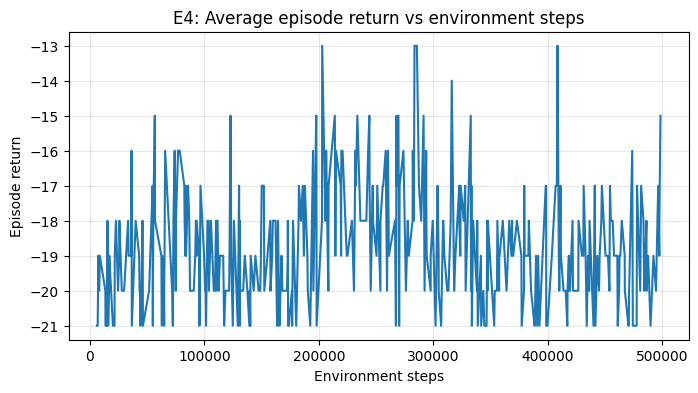

In [10]:
curve_df = pd.DataFrame(episodic_returns, columns=["global_step", "episodic_return"])

plt.figure(figsize=(8, 4))
plt.plot(curve_df["global_step"], curve_df["episodic_return"])
plt.xlabel("Environment steps")
plt.ylabel("Episode return")
plt.title("E4: Average episode return vs environment steps")
plt.grid(True, alpha=0.3)
plt.show()

# Evaluate the trained E4 checkpoint

In [11]:
@torch.no_grad()
def evaluate_e4(checkpoint_path, args, n_episodes=10, save_xai_obs=True):
    env = gym.make(args.env_id)
    env = gym.wrappers.RecordEpisodeStatistics(env)
    env = FireResetEnv(env)
    env = gym.wrappers.AtariPreprocessing(
        env,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,   # true episode eval
        grayscale_obs=True,
        scale_obs=False,
    )
    env = gym.wrappers.FrameStackObservation(env, 4)

    agent = Agent(env.action_space.n).to(args.device)
    ckpt = torch.load(checkpoint_path, map_location=args.device)
    agent.load_state_dict(ckpt["model_state_dict"])
    agent.eval()

    all_returns = []
    saved_obs = []
    saved_actions = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=args.seed + 1000 + ep)
        done = False

        while not done:
            obs_tensor = torch.as_tensor(obs[None], dtype=torch.uint8, device=args.device)
            logits = agent.get_logits(obs_tensor)
            action = torch.argmax(logits, dim=1).item()

            if save_xai_obs and len(saved_obs) < 100:
                saved_obs.append(np.array(obs, copy=True))
                saved_actions.append(action)

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            if done and "episode" in info:
                all_returns.append(float(info["episode"]["r"]))

    env.close()

    xai_obs = np.stack(saved_obs) if len(saved_obs) > 0 else None
    xai_actions = np.array(saved_actions) if len(saved_actions) > 0 else None

    if xai_obs is not None:
        np.savez(
            "/kaggle/working/e4_xai_samples.npz",
            obs=xai_obs,
            actions=xai_actions
        )

    return all_returns, xai_obs, xai_actions

# Run evaluation and save XAI samples

In [12]:
eval_returns, xai_obs, xai_actions = evaluate_e4(checkpoint_path, args, n_episodes=10, save_xai_obs=True)

print("Evaluation returns:", eval_returns)
print("Mean eval return:", np.mean(eval_returns))
print("Std eval return:", np.std(eval_returns))

if xai_obs is not None:
    print("Saved XAI observations shape:", xai_obs.shape)
    print("Saved XAI actions shape:", xai_actions.shape)
    print("Saved file: /kaggle/working/e4_xai_samples.npz")

Evaluation returns: [-21.0, -21.0, -21.0, -21.0, -21.0, -21.0, -21.0, -21.0, -21.0, -21.0]
Mean eval return: -21.0
Std eval return: 0.0
Saved XAI observations shape: (100, 4, 84, 84)
Saved XAI actions shape: (100,)
Saved file: /kaggle/working/e4_xai_samples.npz


# Show a few saved frames for later Grad-CAM analysis

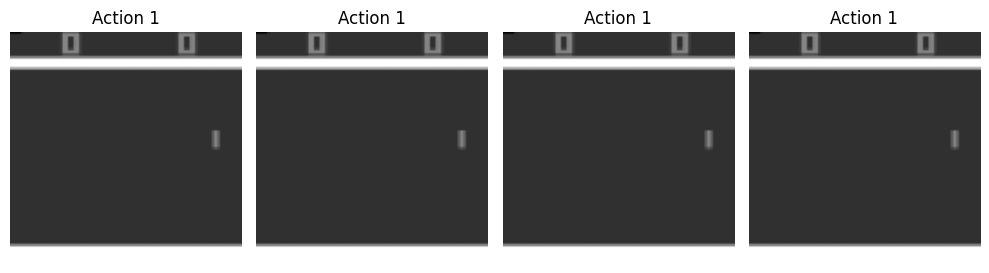

In [13]:
if xai_obs is not None:
    plt.figure(figsize=(10, 4))
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        # show the latest frame from the 4-frame stack
        if xai_obs.shape[1] == 4:
            img = xai_obs[i][-1]
        else:
            img = xai_obs[i][..., -1]
        plt.imshow(img, cmap="gray")
        plt.title(f"Action {xai_actions[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Pilot sweep for E4

In [ ]:
pilot_results = []

for head_lr in [1e-4, 3e-4, 1e-3]:
    for enc_lr in [1e-5, 1e-4]:
        for clip in [0.1, 0.2]:
            args.learning_rate = head_lr
            args.encoder_lr = enc_lr
            args.clip_coef = clip
            args.seed = 1

            print(f"\nRunning config: head_lr={head_lr}, enc_lr={enc_lr}, clip={clip}")
            checkpoint_path, episodic_returns = train_e4(args)
            eval_returns, _, _ = evaluate_e4(checkpoint_path, args, n_episodes=5, save_xai_obs=False)

            pilot_results.append({
                "head_lr": head_lr,
                "encoder_lr": enc_lr,
                "clip_coef": clip,
                "mean_eval_return": float(np.mean(eval_returns)),
                "std_eval_return": float(np.std(eval_returns)),
                "checkpoint": checkpoint_path
            })

pilot_df = pd.DataFrame(pilot_results).sort_values("mean_eval_return", ascending=False)
pilot_df


Running config: head_lr=0.0001, enc_lr=1e-05, clip=0.1
update 1/488 | step 1024 | recent mean return nan | fps 67
update 10/488 | step 10240 | recent mean return -20.29 | fps 64
update 20/488 | step 20480 | recent mean return -20.60 | fps 64
update 30/488 | step 30720 | recent mean return -20.30 | fps 64
update 40/488 | step 40960 | recent mean return -19.90 | fps 64
update 50/488 | step 51200 | recent mean return -20.20 | fps 64
update 60/488 | step 61440 | recent mean return -19.90 | fps 64
update 70/488 | step 71680 | recent mean return -20.40 | fps 64
update 80/488 | step 81920 | recent mean return -20.50 | fps 64
update 90/488 | step 92160 | recent mean return -19.70 | fps 64
update 100/488 | step 102400 | recent mean return -19.60 | fps 64
update 110/488 | step 112640 | recent mean return -19.80 | fps 64
update 120/488 | step 122880 | recent mean return -19.70 | fps 64
update 130/488 | step 133120 | recent mean return -20.10 | fps 64
update 140/488 | step 143360 | recent mean re